# Раздел 1: Data Acquisition & Risk Filtering (Absolute Momentum)

В этом блоке мы выделяем активы, которые показывают сильный импульс роста, но при этом сохраняют историческую «просадку» в пределах 5%, что является критическим фильтром для нашего гибридного портфеля.

✅ Период анализа: 2024-01-01 — 2026-03-27
🎯 Лимит риска: Max Drawdown > -5.00%
📊 Прошли фильтр: SGD, EUR, CHF, PLN, NOK



Ticker,CAGR (%),Downside Vol (%),Max Drawdown (%),Sortino
SGD,2.00%,1.19%,-1.87%,1.69
ILS,5.38%,3.60%,-5.17%,1.50
EUR,2.58%,2.37%,-3.24%,1.09
SEK,3.38%,4.23%,-5.26%,0.80
CHF,2.92%,3.73%,-4.69%,0.78
PLN,3.18%,4.10%,-4.64%,0.78
NOK,2.73%,5.16%,-4.85%,0.53
COP,3.05%,7.04%,-13.75%,0.43
AUD,1.51%,4.56%,-10.37%,0.33
NZD,-2.13%,4.39%,-11.21%,-0.49


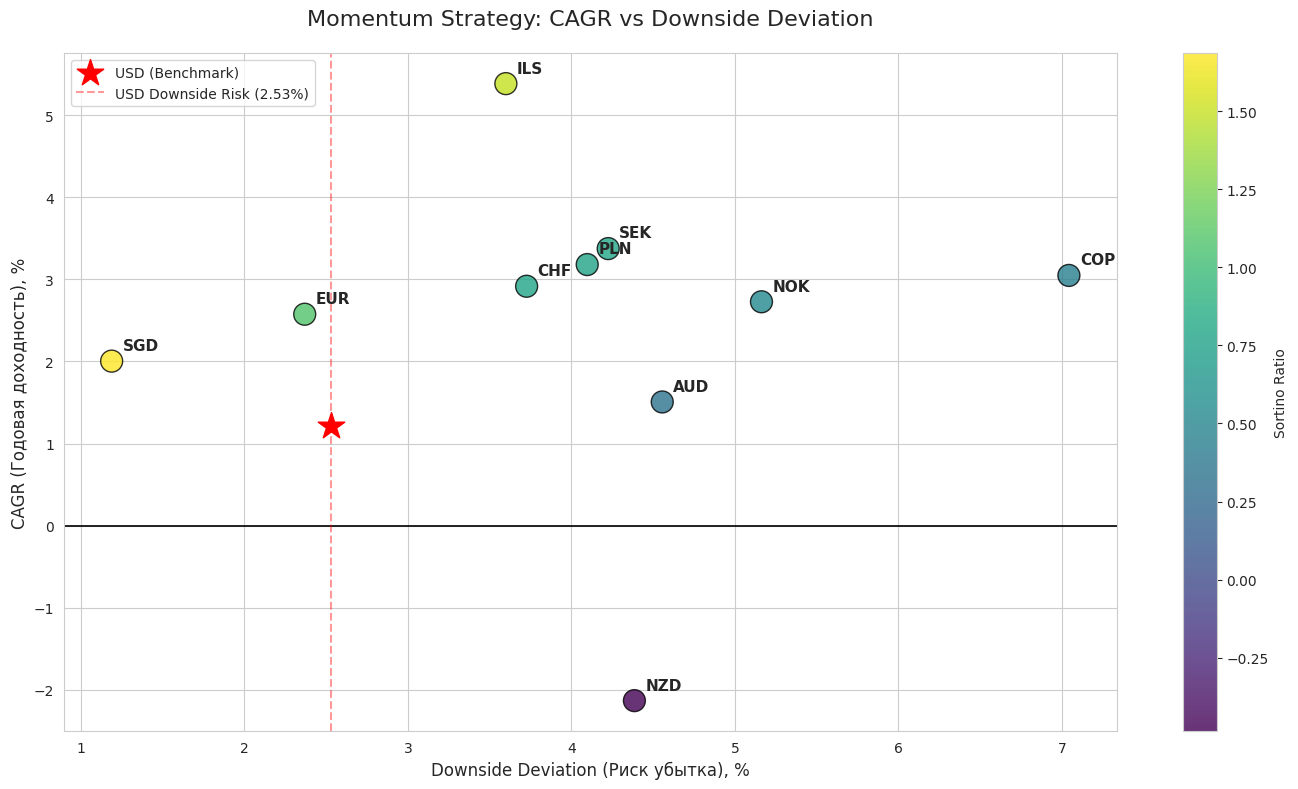

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# --- 1.1. Загрузка и первичная очистка ---
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Date']).sort_values('Date').set_index('Date')

# Устанавливаем горизонт: Январь 2024 — Март 2026
start_date = '2024-01-01'
end_date = df_raw.index.max()
df_prices = df_raw.loc[start_date:end_date].copy()
df_prices = df_prices.dropna(axis=1).ffill().bfill()
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# --- 1.2. Определение пула активов ---
target_tickers = ['SGD', 'EUR', 'COP', 'PLN', 'CHF', 'ILS', 'NOK', 'SEK', 'AUD', 'NZD']
benchmark_ticker = 'USD'

available_tickers = [t for t in target_tickers if t in df_returns.columns]

# --- 1.3. Расчет риск-метрик в процентах ---
def get_metrics_pct(returns_series):
    """Расчет метрик в процентном выражении"""
    # CAGR в %
    cagr = (returns_series.mean() * 252) * 100
    
    # Downside Deviation (только отрицательные доходности) в %
    downside_returns = returns_series[returns_series < 0]
    downside_vol = (downside_returns.std() * np.sqrt(252)) * 100
    
    # Max Drawdown в %
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    mdd = drawdown.min() * 100
    
    # Sortino Ratio (безразмерный коэффициент)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    return cagr, downside_vol, mdd, sortino

# --- 1.4. Сбор статистики ---
stats = []
for ticker in available_tickers:
    c, dv, mdd, s = get_metrics_pct(df_returns[ticker])
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    link = f'<a href="{url}" target="_blank">{ticker}</a>'
    
    stats.append({
        'Ticker': link,
        'CAGR (%)': c,
        'Downside Vol (%)': dv,
        'Max Drawdown (%)': mdd,
        'Sortino': s
    })

df_stats = pd.DataFrame(stats).sort_values('Sortino', ascending=False)

# Фильтрация по MDD > -5% (строго по ТЗ)
df_filtered = df_stats[df_stats['Max Drawdown (%)'] > -5.0].copy()

# Форматирование таблицы для отображения
df_display = df_stats.copy()
format_cols = ['CAGR (%)', 'Downside Vol (%)', 'Max Drawdown (%)']
for col in format_cols:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}%")
df_display['Sortino'] = df_display['Sortino'].apply(lambda x: round(x, 2))

# --- Контроль и вывод ---
print(f"✅ Период анализа: {start_date} — {end_date.date()}")
print(f"🎯 Лимит риска: Max Drawdown > -5.00%")
print(f"📊 Прошли фильтр: {', '.join([t.split('>')[-2].split('<')[0] for t in df_filtered['Ticker']])}\n")

display(HTML(df_display.to_html(escape=False, index=False)))

# --- 1.5. Визуализация: Доходность vs Downside Risk (в %) ---
plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("whitegrid")

# Точки активов
sc = plt.scatter(df_stats['Downside Vol (%)'], df_stats['CAGR (%)'], 
                c=df_stats['Sortino'], cmap='viridis', s=250, edgecolors='black', alpha=0.8)

# Метрики бенчмарка USD
u_c, u_dv, u_mdd, u_s = get_metrics_pct(df_returns[benchmark_ticker])
plt.scatter(u_dv, u_c, color='red', s=400, marker='*', label='USD (Benchmark)', zorder=5)

# Аннотации тикеров
for i, row in df_stats.iterrows():
    clean_ticker = row['Ticker'].split('>')[-2].split('<')[0]
    plt.annotate(clean_ticker, (row['Downside Vol (%)'], row['CAGR (%)']), 
                 xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.colorbar(sc, label='Sortino Ratio')
plt.axhline(0, color='black', lw=1.2, ls='-')
plt.axvline(u_dv, color='red', linestyle='--', alpha=0.4, label=f'USD Downside Risk ({u_dv:.2f}%)')

# Отрисовка зоны фильтра (опционально, если риск по осям позволяет)
plt.title("Momentum Strategy: CAGR vs Downside Deviation", fontsize=16, pad=20)
plt.xlabel("Downside Deviation (Риск убытка), %", fontsize=12)
plt.ylabel("CAGR (Годовая доходность), %", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### 🔍 Аналитический отчет: Первичный скрининг и риск-фильтрация (Absolute Momentum)

На основе данных за период с января 2024 по март 2026 года проведен анализ 10 валютных активов. Основной фокус исследования смещен с общей волатильности на **Downside Deviation** (риск убыточных отклонений) и **Max Drawdown** (максимальная историческая просадка) для максимизации **Sortino Ratio**.

**Ключевые выводы по активам:**

* **Эталон эффективности:** [SGD](https://www.abscur.ru/p/2.html?abs=SGD) демонстрирует самый высокий коэффициент Сортино (**1.69**). При CAGR в **2.00%** его риск убытка минимален (Downside Vol **1.19%**, MDD **-1.87%**). Это подтверждает его статус главного защитного актива в гибридном портфеле.
* **Аномалия доходности:** [ILS](https://www.abscur.ru/p/2.html?abs=ILS) показал максимальную доходность (**5.38%**) и высокий Сортино (**1.50**), однако актив **не прошел жесткий фильтр** (MDD **-5.17%** при лимите в -5.00%). Это исключает его из консервативной части, но оставляет в поле зрения для спекулятивных маневров.
* **Ядро импульса (Momentum):** Валюты [EUR](https://www.abscur.ru/p/2.html?abs=EUR), [CHF](https://www.abscur.ru/p/2.html?abs=CHF) и [PLN](https://www.abscur.ru/p/2.html?abs=PLN) успешно преодолели фильтр просадки. Особого внимания заслуживает [PLN](https://www.abscur.ru/p/2.html?abs=PLN), чей CAGR в **3.18%** значительно выше, чем у евро, при сохранении допустимого уровня риска.
* **Зона высокого риска:** [COP](https://www.abscur.ru/p/2.html?abs=COP) и [AUD](https://www.abscur.ru/p/2.html?abs=AUD) показали просадки более **-10%**, что делает их использование в текущей стратегии невозможным без значительного сокращения доли. [NZD](https://www.abscur.ru/p/2.html?abs=NZD) — единственный актив с отрицательной доходностью, что делает его контрпродуктивным для Momentum-стратегии.

**Связь с теорией абсолютных курсов:**
Текущий цикл подтверждает превосходство «тихих гаваней» ([SGD](https://www.abscur.ru/p/2.html?abs=SGD)) и валют с сильным внутренним импульсом ([PLN](https://www.abscur.ru/p/2.html?abs=PLN)) над традиционными сырьевыми валютами в разрезе риск-корректированной доходности.

# 2. Momentum & Downside Risk Profile: Анализ целевых активов (SGD, EUR, COP, PLN, CHF и др.) через призму коэффициента Сортино.

# 3. Hybrid Portfolio Optimization (Monte Carlo): Поиск оптимальных весов для максимизации Sortino Ratio при заданных ограничениях риска.

# 4. Equity Curve & Benchmark Comparison: Сравнение гибрида с USD и Gold (XAU).

# 5. Performance Attribution (Waterfall): Декомпозиция вклада каждой валюты в итоговый результат.